This notebook is created to apply Kalman Filters using IMU, VO and GPS data corrected by the PX4 drone.

In [1]:
import os
import sys
src_dir = "../../src"
if src_dir not in sys.path:
    sys.path.append(src_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d
from datetime import datetime
import seaborn as sns
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
from filterpy.monte_carlo import (
    multinomial_resample, residual_resample, systematic_resample, stratified_resample
)
from utils.error_report import get_error_from_list, get_error_report
from utils import lla_to_enu, lla_to_ned

from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, SamplingEnum, ErrorEnum
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter
from numpy.linalg import norm
from decimal import Decimal, getcontext
from ahrs.filters import Madgwick

%matplotlib inline
np.random.seed(777)

In [2]:
root_path = "../../"

file_export_path = os.path.join(root_path, "exports/UAV")

uav_root_path = os.path.join(root_path, "data/UAV/log0000")
uav_reference_path = os.path.join(root_path, "data/UAV/v3/combined_log0000.csv")

px4_root_path = os.path.join(uav_root_path, "px4/13_07_41")
px4_imu0_path = os.path.join(px4_root_path, "imu_combined/log0000_px4_imu0_combined.csv")
px4_imu1_path = os.path.join(px4_root_path, "imu_combined/log0000_px4_imu1_combined.csv")
px4_gps_path = os.path.join(px4_root_path, "13_07_41_sensor_gps_0.csv")
px4_vo_path = os.path.join(px4_root_path, "13_07_41_vehicle_visual_odometry_0.csv")
imu0_bias_path = os.path.join(px4_root_path, "13_07_41_estimator_sensor_bias_0.csv")
imu1_bias_path = os.path.join(px4_root_path, "13_07_41_estimator_sensor_bias_1.csv")

voxl_root_path = os.path.join(uav_root_path, "run/mpa")
voxl_imu0_path = os.path.join(voxl_root_path, "imu0/data.csv")
voxl_imu1_path = os.path.join(voxl_root_path, "imu1/data.csv")
voxl_qvio_path = os.path.join(voxl_root_path, "qvio/data.csv")

ref_df = pd.read_csv(uav_reference_path)

px4_imu0_df = pd.read_csv(px4_imu0_path)
px4_imu1_df = pd.read_csv(px4_imu1_path)
px4_gps_df = pd.read_csv(px4_gps_path)
px4_vo_df = pd.read_csv(px4_vo_path)
imu0_bias_df = pd.read_csv(imu0_bias_path)
imu1_bias_df = pd.read_csv(imu1_bias_path)

voxl_imu0_df = pd.read_csv(voxl_imu0_path)
voxl_imu1_df = pd.read_csv(voxl_imu1_path)
voxl_qvio_df = pd.read_csv(voxl_qvio_path)

In [4]:
# Convert lla(Int) into lla(float)

getcontext().prec = 10
def int2float_lla(x):
    return float(Decimal(x / Decimal(10**(len(str(x)) - 2))))

def int_lla_to_float_lla(df):
    df['lat'] = df['lat'].apply(lambda x: int2float_lla(x))
    df['lon'] = df['lon'].apply(lambda x: int2float_lla(x))
    df['alt'] = df['alt'].apply(lambda x: int2float_lla(x))
    
int_lla_to_float_lla(px4_gps_df)

In [5]:
# Convert lla into North-East-Down coordinate in meter

def get_ned_coord(df):    
    origin = df[['lon', 'lat', 'alt']].iloc[0].values
    ned_pose = lla_to_ned(df[['lon', 'lat', 'alt']].values.T, origin).T
    df = pd.concat([
        df,
        pd.DataFrame(ned_pose, columns=['north', 'east', 'down'])
    ], axis=1)
    return df

px4_gps_df = get_ned_coord(px4_gps_df)

In [6]:
def print_error_report(report, title):
    print(f"----- {title} -----")
    print(f"Mean Absolute Error: {report[ErrorEnum.MAE]}")
    print(f"Root Mean Squared Error: {report[ErrorEnum.RMSE]}")
    print(f"Maximum Error: {report[ErrorEnum.MAX]}")
    print("")

In [7]:
ref_df['device'].value_counts()

device
voxl_imu1        67564
voxl_imu0        60224
px4_imu0         14757
px4_imu1         14706
voxl_vo           1782
px4_vo            1573
px4_gps            422
px4_imu0_bias      344
px4_imu1_bias      295
Name: count, dtype: int64

In [8]:
time_update = ['voxl_imu0', 'voxl_imu0', 'px4_imu0', 'px4_imu1', 'px4_imu0_bias', 'px4_imu1_bias']
measurement_update = ['voxl_vo', 'px4_vo', 'px4_gps']

SENSOR_SLIP_THRESHOLD = 2 # 2 seconds

def get_config(timestamp):

    return {
        'voxl_imu0': {
            'index': 0,
            'last_timestamp': timestamp,
            'columns': ['AX(m/s2)', 'AY(m/s2)', 'AZ(m/s2)', 'GX(rad/s)', 'GY(rad/s)', 'GZ(rad/s)'],
            'df': voxl_imu0_df,
        },
        'voxl_imu1': {
            'index': 0,
            'last_timestamp': timestamp,
            'columns': ['AX(m/s2)', 'AY(m/s2)', 'AZ(m/s2)', 'GX(rad/s)', 'GY(rad/s)', 'GZ(rad/s)'],
            'df': voxl_imu1_df,
        },
        'px4_imu0': {
            'index': 0,
            'last_timestamp': timestamp,
            'columns': ['AX(m/s2)', 'AY(m/s2)', 'AZ(m/s2)', 'GX(rad/s)', 'GY(rad/s)', 'GZ(rad/s)'],
            'df': px4_imu0_df,
        },
        'px4_imu1': {
            'index': 0,
            'last_timestamp': timestamp,
            'columns': ['AX(m/s2)', 'AY(m/s2)', 'AZ(m/s2)', 'GX(rad/s)', 'GY(rad/s)', 'GZ(rad/s)'],
            'df': px4_imu1_df,
        },
        'px4_gps': {
            'index': 0,
            'last_timestamp': timestamp,
            'columns': ['lat', 'lon', 'alt', 'north', 'east', 'down', 'vel_m_s', 'vel_n_m_s', 'vel_e_m_s', 'vel_d_m_s'],
            'df': px4_gps_df,
        },
        'px4_vo': {
            'index': 0,
            'last_timestamp': timestamp,
            'columns': ['position[0]', 'position[1]', 'position[2]', 
                        'q[0]', 'q[1]', 'q[2]', 'q[3]', 
                        'velocity[0]','velocity[1]', 'velocity[2]', 
                        'angular_velocity[0]', 'angular_velocity[1]', 'angular_velocity[2]', 
                        'position_variance[0]', 'position_variance[1]', 'position_variance[2]',
                        'orientation_variance[0]', 'orientation_variance[1]', 'orientation_variance[2]', 
                        'velocity_variance[0]', 'velocity_variance[1]', 'velocity_variance[2]'],
            'df': px4_vo_df,
        },
        'px4_imu0_bias': {
            'index': 0,
            'last_timestamp': timestamp,
            'columns': ['gyro_bias[0]', 'gyro_bias[1]', 'gyro_bias[2]', 'accel_bias[0]', 'accel_bias[1]', 'accel_bias[2]'],
            'df': imu0_bias_df,
        },
        'px4_imu1_bias': {
            'index': 0,
            'last_timestamp': timestamp,
            'columns': ['gyro_bias[0]', 'gyro_bias[1]', 'gyro_bias[2]', 'accel_bias[0]', 'accel_bias[1]', 'accel_bias[2]'],
            'df': imu1_bias_df,
        },
        'voxl_vo': {
            'index': 0,
            'last_timestamp': timestamp,
            'columns': voxl_qvio_df.columns.tolist(),
            'df': voxl_qvio_df,
        },
    }

In [10]:
px4_vo_df[['position_variance[0]', 'position_variance[1]', 'position_variance[2]']]

,position_variance[0],position_variance[1],position_variance[2]
0,1.223021e-07,1.764630e-07,1.014742e-07
1,1.223719e-07,1.765402e-07,1.015430e-07
2,1.223710e-07,1.766025e-07,1.016036e-07
3,1.226655e-07,1.767888e-07,1.017239e-07
4,1.218612e-07,1.759711e-07,1.016142e-07
...,...,...,...
1568,NaN,NaN,NaN
1569,NaN,NaN,NaN
1570,NaN,NaN,NaN
1571,NaN,NaN,NaN


## Apply Kalman Filter using voxl IMU, VO(px4) and GPS

In [8]:
df1 = ref_df.loc[
            (ref_df["device"] == "voxl_imu0") | 
            (ref_df["device"] == "px4_vo") |
            (ref_df["device"] == "px4_gps")]

In [9]:
df1["device"].value_counts()

device
voxl_imu0    60224
px4_vo        1573
px4_gps        422
Name: count, dtype: int64

In [10]:
gps_pose_columns = ['lon', 'lat', 'alt']
gps_ned_pose_columns = ['north', 'east', 'down']
vo_pos_columns = ['position[0]', 'position[1]', 'position[2]']
vo_pos_var_columns = ['position_variance[0]', 'position_variance[1]', 'position_variance[2]']

### EKF

In [11]:
x = np.array([
    [px4_gps_df.iloc[0]['north']],
    [px4_gps_df.iloc[0]['east']],
    [px4_gps_df.iloc[0]['down']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.01, 0.01, 0.01, 0.0035, 0.0035, 0.0035])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

In [12]:
ekf = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1
)

ekf_imu_gps = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1
)

In [13]:
t_last = df1.iloc[0]['timestamp']
df_reference = get_config(timestamp=t_last)
original_position = px4_gps_df[['lon', 'lat', 'alt']].iloc[0].values

ekf_mu_x = [x[0][0]]
ekf_mu_y = [x[1][0]]
ekf_mu_z = [x[2][0]]

ekf_imu_gps_mu_x = [x[0][0]]
ekf_imu_gps_mu_y = [x[1][0]]
ekf_imu_gps_mu_z = [x[2][0]]

N = len(df1.values)
for idx in tqdm(range(0, N)):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000
    # dt = (data_ref['timestamp'] - t_last) / 1_000_000 # delta time in second

    if dt < SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in time_update:
            # Call Time update step
            ekf.predict_setup1_2(u=data.values, dt=dt, Q=ekf.Q)
            ekf_imu_gps.predict_setup1_2(u=data.values, dt=dt, Q=ekf_imu_gps.Q)
            
        elif data_ref['device'] in measurement_update:
            # Call Measurement update step
            if data_ref['device'] == 'px4_gps':
                x_hat = ekf.x.copy()
                ekf_mu_x.append(x_hat[0, 0])
                ekf_mu_y.append(x_hat[1, 0])
                ekf_mu_z.append(x_hat[2, 0])
                x_hat2 = ekf_imu_gps.x.copy()
                ekf_imu_gps_mu_x.append(x_hat2[0, 0])
                ekf_imu_gps_mu_y.append(x_hat2[1, 0])
                ekf_imu_gps_mu_z.append(x_hat2[2, 0])
                
                gps_ned = lla_to_ned(
                    sensor["df"].iloc[sensor['index']:sensor['index'] + 1][gps_pose_columns].values.T,
                    original_position
                ).T[0]
                z = np.array([
                    gps_ned[0],
                    gps_ned[1],
                    gps_ned[2],
                ])
                ekf.update(z=z, R=ekf.R_gps)            
                
                ekf_imu_gps.update(z=z, R=ekf_imu_gps.R_gps)
                
            elif data_ref['device'] == 'px4_vo':
                z = sensor["df"].iloc[sensor["index"]][vo_pos_columns].values
                r_vo = sensor["df"].iloc[sensor["index"]][vo_pos_var_columns].values
                if np.isnan(r_vo.sum()):
                    R_vo = ekf.R_vo
                else:
                    R_vo = np.eye(r_vo.shape[0]) * r_vo
                
                ekf.update(z=z, R=R_vo)
                

    # t_last = data_ref['timestamp']
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1

100%|█████████████████████████████████████████████████████████████████████████████████| 62219/62219 [00:20<00:00, 3047.88it/s]


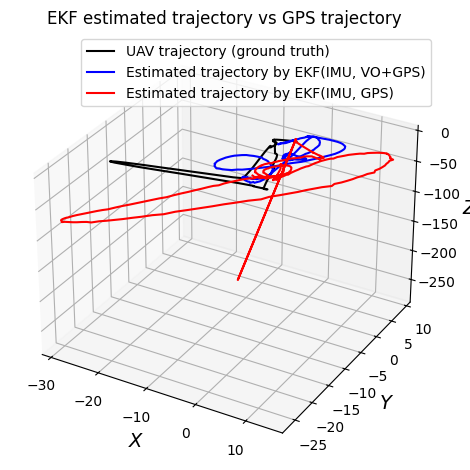

In [14]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("EKF estimated trajectory vs GPS trajectory")

ax1.plot(px4_gps_df['north'].values, 
         px4_gps_df['east'].values, 
         px4_gps_df['down'].values, 
         label='UAV trajectory (ground truth)', 
         color='black')
ax1.plot(ekf_mu_x, ekf_mu_y, ekf_mu_z, label='Estimated trajectory by EKF(IMU, VO+GPS)', color='blue')
ax1.plot(ekf_imu_gps_mu_x, ekf_imu_gps_mu_y, ekf_imu_gps_mu_z, label='Estimated trajectory by EKF(IMU, GPS)', color='red')

ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)
fig.tight_layout()

In [15]:
ekf_imu_vo_gps_error = get_error_report(px4_gps_df[gps_ned_pose_columns].values, 
                            np.array([ekf_mu_x, ekf_mu_y, ekf_mu_z]).T)
ekf_imu_gps_error = get_error_report(px4_gps_df[gps_ned_pose_columns].values, 
                            np.array([ekf_imu_gps_mu_x, ekf_imu_gps_mu_y, ekf_imu_gps_mu_z]).T)

print_error_report(
    report=ekf_imu_vo_gps_error,
    title="Deviation between EKF(IMU, VO+GPS) estimated pose and GPS"
)

print_error_report(
    report=ekf_imu_gps_error,
    title="Deviation between EKF(IMU, GPS) estimated pose and GPS"
)

----- Deviation between EKF(IMU, VO+GPS) estimated pose and GPS -----
Mean Absolute Error: 8.101
Root Mean Squared Error: 11.75
Maximum Error: 30.402

----- Deviation between EKF(IMU, GPS) estimated pose and GPS -----
Mean Absolute Error: 14.6
Root Mean Squared Error: 24.629
Maximum Error: 283.421



### UKF

In [16]:
x = np.array([
    [px4_gps_df.iloc[0]['north']],
    [px4_gps_df.iloc[0]['east']],
    [px4_gps_df.iloc[0]['down']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

alpha_setup = 10.
beta_setup = 2.
kappa_setup = 0.

ukf = UnscentedKalmanFilter(
    x=x.copy(), 
    P=P.copy(),
    H=H.copy(), 
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    alpha=alpha_setup, 
    beta=beta_setup, 
    kappa=kappa_setup,
    setup=SetupEnum.SETUP_1
)

ukf_imu_gps = UnscentedKalmanFilter(
    x=x.copy(), 
    P=P.copy(),
    H=H.copy(), 
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    alpha=alpha_setup, 
    beta=beta_setup, 
    kappa=kappa_setup,
    setup=SetupEnum.SETUP_1
)

In [17]:
t_last = df1.iloc[0]['timestamp']
df_reference = get_config(timestamp=t_last)
original_position = px4_gps_df[['lon', 'lat', 'alt']].iloc[0].values

ukf_mu_x = [x[0][0]]
ukf_mu_y = [x[1][0]]
ukf_mu_z = [x[2][0]]

ukf_imu_gps_mu_x = [x[0][0]]
ukf_imu_gps_mu_y = [x[1][0]]
ukf_imu_gps_mu_z = [x[2][0]]

N = len(df1.values)
for idx in tqdm(range(0, N)):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000
    # dt = (data_ref['timestamp'] - t_last) / 1_000_000 # delta time in second

    if dt < SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in time_update:
            # Call Time update step
            ukf.predict_setup1_2(u=data.values, dt=dt, Q=ukf.Q)
            ukf_imu_gps.predict_setup1_2(u=data.values, dt=dt, Q=ukf_imu_gps.Q)
            
        elif data_ref['device'] in measurement_update:
            # Call Measurement update step
            if data_ref['device'] == 'px4_gps':
                x_hat = ukf.x.copy()
                ukf_mu_x.append(x_hat[0, 0])
                ukf_mu_y.append(x_hat[1, 0])
                ukf_mu_z.append(x_hat[2, 0])
                x_hat2 = ukf_imu_gps.x.copy()
                ukf_imu_gps_mu_x.append(x_hat2[0, 0])
                ukf_imu_gps_mu_y.append(x_hat2[1, 0])
                ukf_imu_gps_mu_z.append(x_hat2[2, 0])
                
                gps_ned = lla_to_ned(
                    sensor["df"].iloc[sensor['index']:sensor['index'] + 1][gps_pose_columns].values.T,
                    original_position
                ).T[0]
                z = np.array([
                    gps_ned[0],
                    gps_ned[1],
                    gps_ned[2],
                ])
                ukf.update(z=z, R=ukf.R_gps)

                ukf_imu_gps.update(z=z, R=ukf_imu_gps.R_gps)
                
            elif data_ref['device'] == 'px4_vo':
                z = sensor["df"].iloc[sensor["index"]][vo_pos_columns].values
                r_vo = sensor["df"].iloc[sensor["index"]][vo_pos_var_columns].values
                if np.isnan(r_vo.sum()):
                    R_vo = ukf.R_vo
                else:
                    R_vo = np.eye(r_vo.shape[0]) * r_vo
                
                ukf.update(z=z, R=R_vo)
                

    # t_last = data_ref['timestamp']
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1

100%|█████████████████████████████████████████████████████████████████████████████████| 62219/62219 [00:45<00:00, 1372.62it/s]


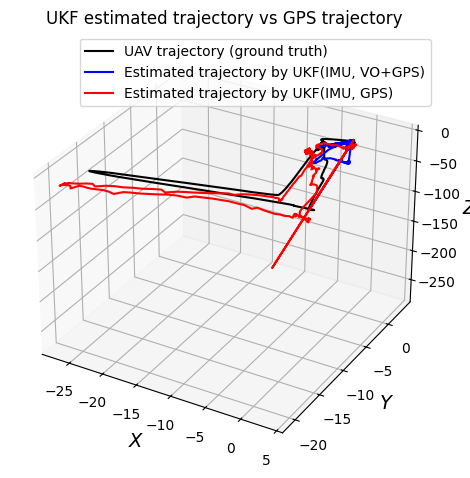

In [18]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("UKF estimated trajectory vs GPS trajectory")

ax1.plot(px4_gps_df['north'].values, 
         px4_gps_df['east'].values, 
         px4_gps_df['down'].values, 
         label='UAV trajectory (ground truth)', 
         color='black')
ax1.plot(ukf_mu_x, ukf_mu_y, ukf_mu_z, label='Estimated trajectory by UKF(IMU, VO+GPS)', color='blue')
ax1.plot(ukf_imu_gps_mu_x, ukf_imu_gps_mu_y, ukf_imu_gps_mu_z, label='Estimated trajectory by UKF(IMU, GPS)', color='red')

ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)
fig.tight_layout()

In [19]:
ukf_imu_vo_gps_error = get_error_report(px4_gps_df[gps_ned_pose_columns].values, 
                            np.array([ukf_mu_x, ukf_mu_y, ukf_mu_z]).T)
ukf_imu_gps_error = get_error_report(px4_gps_df[gps_ned_pose_columns].values, 
                            np.array([ukf_imu_gps_mu_x, ukf_imu_gps_mu_y, ukf_imu_gps_mu_z]).T)

print_error_report(
    report=ukf_imu_vo_gps_error,
    title="Deviation between UKF(IMU, VO+GPS) estimated pose and GPS"
)

print_error_report(
    report=ukf_imu_gps_error,
    title="Deviation between UKF(IMU, GPS) estimated pose and GPS"
)

----- Deviation between UKF(IMU, VO+GPS) estimated pose and GPS -----
Mean Absolute Error: 4.912
Root Mean Squared Error: 8.036
Maximum Error: 141.621

----- Deviation between UKF(IMU, GPS) estimated pose and GPS -----
Mean Absolute Error: 3.488
Root Mean Squared Error: 10.474
Maximum Error: 282.745



### PF

In [20]:
x = np.array([
    [px4_gps_df.iloc[0]['north']],
    [px4_gps_df.iloc[0]['east']],
    [px4_gps_df.iloc[0]['down']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

importance_resampling = True

pf = ParticleFilter(
    N=2048, 
    x_dim=x.shape[0], 
    H=H.copy(), 
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1,
    resampling_algorithm=ResamplingAlgorithms.STRATIFIED)
pf.create_gaussian_particles(mean=x.copy(), var=P.copy())

pf_imu_gps = ParticleFilter(
    N=2048, 
    x_dim=x.shape[0], 
    H=H.copy(), 
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1,
    resampling_algorithm=ResamplingAlgorithms.STRATIFIED)
pf_imu_gps.create_gaussian_particles(mean=x.copy(), var=P.copy())

In [21]:
t_last = df1.iloc[0]['timestamp']
df_reference = get_config(timestamp=t_last)
original_position = px4_gps_df[['lon', 'lat', 'alt']].iloc[0].values

pf_mu_x = [x[0][0]]
pf_mu_y = [x[1][0]]
pf_mu_z = [x[2][0]]

pf_imu_gps_mu_x = [x[0][0]]
pf_imu_gps_mu_y = [x[1][0]]
pf_imu_gps_mu_z = [x[2][0]]

N = len(df1.values)
for idx in tqdm(range(0, N)):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000
    # dt = (data_ref['timestamp'] - t_last) / 1_000_000 # delta time in second

    if dt < SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in time_update:
            # Call Time update step
            pf.predict_setup1_2(u=data.values, dt=dt, Q=pf.Q)
            pf_imu_gps.predict_setup1_2(u=data.values, dt=dt, Q=pf_imu_gps.Q)
            
        elif data_ref['device'] in measurement_update:
            # Call Measurement update step
            if data_ref['device'] == 'px4_gps':
                x_hat, _ = pf.estimate()
                pf_mu_x.append(x_hat[0])
                pf_mu_y.append(x_hat[1])
                pf_mu_z.append(x_hat[2])
                
                x_hat2, _ = pf_imu_gps.estimate()
                pf_imu_gps_mu_x.append(x_hat2[0])
                pf_imu_gps_mu_y.append(x_hat2[1])
                pf_imu_gps_mu_z.append(x_hat2[2])

                
                gps_ned = lla_to_ned(
                    sensor["df"].iloc[sensor['index']:sensor['index'] + 1][gps_pose_columns].values.T,
                    original_position
                ).T[0]
                z = np.array([
                    gps_ned[0],
                    gps_ned[1],
                    gps_ned[2],
                ])
                pf.update(z, R=pf.R_gps)
                
                pf_imu_gps.update(z, R=pf_imu_gps.R_gps)
                
            elif data_ref['device'] == 'px4_vo':
                z = sensor["df"].iloc[sensor["index"]][vo_pos_columns].values
                r_vo = sensor["df"].iloc[sensor["index"]][vo_pos_var_columns].values
                if np.isnan(r_vo.sum()):
                    R_vo = pf.R_vo
                else:
                    R_vo = np.eye(r_vo.shape[0]) * r_vo
                
                pf.update(z, R=R_vo)
                
            if pf.allow_resampling(importance_resampling=importance_resampling):
                pf.resample()

    # t_last = data_ref['timestamp']
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1

100%|███████████████████████████████████████████████████████████████████████████████████| 62219/62219 [39:56<00:00, 25.96it/s]


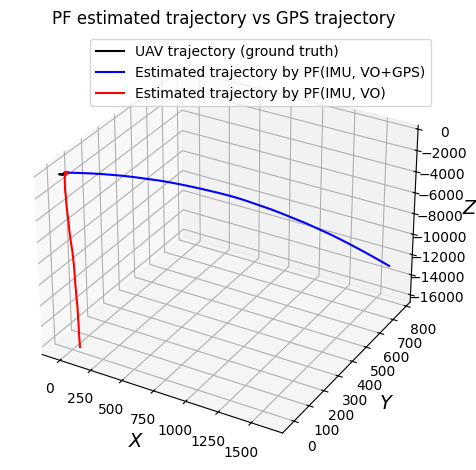

In [22]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("PF estimated trajectory vs GPS trajectory")

ax1.plot(px4_gps_df['north'].values, 
         px4_gps_df['east'].values, 
         px4_gps_df['down'].values, 
         label='UAV trajectory (ground truth)', 
         color='black')
ax1.plot(pf_mu_x, pf_mu_y, pf_mu_z, label='Estimated trajectory by PF(IMU, VO+GPS)', color='blue')
ax1.plot(pf_imu_gps_mu_x, pf_imu_gps_mu_y, pf_imu_gps_mu_z, label='Estimated trajectory by PF(IMU, VO)', color='red')

ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)
fig.tight_layout()

In [23]:
pf_imu_vo_gps_error = get_error_report(px4_gps_df[gps_ned_pose_columns].values, 
                            np.array([pf_mu_x, pf_mu_y, pf_mu_z]).T)
pf_imu_gps_error = get_error_report(px4_gps_df[gps_ned_pose_columns].values, 
                            np.array([pf_imu_gps_mu_x, pf_imu_gps_mu_y, pf_imu_gps_mu_z]).T)

print_error_report(
    report=pf_imu_vo_gps_error,
    title="Deviation between PF(IMU, VO+GPS) estimated pose and GPS"
)

print_error_report(
    report=pf_imu_gps_error,
    title="Deviation between PF(IMU, GPS) estimated pose and GPS"
)

----- Deviation between PF(IMU, VO+GPS) estimated pose and GPS -----
Mean Absolute Error: 1656.924
Root Mean Squared Error: 3266.243
Maximum Error: 12799.359

----- Deviation between PF(IMU, GPS) estimated pose and GPS -----
Mean Absolute Error: 2011.791
Root Mean Squared Error: 4442.927
Maximum Error: 16390.529



### EnKF

In [24]:
x = np.array([
    [px4_gps_df.iloc[0]['north']],
    [px4_gps_df.iloc[0]['east']],
    [px4_gps_df.iloc[0]['down']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

n_ensemble = 64
enkf = EnsembleKalmanFilter(
    N=n_ensemble, 
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1)

enkf_imu_gps = EnsembleKalmanFilter(
    N=n_ensemble, 
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1)
    

In [25]:
t_last = df1.iloc[0]['timestamp']
df_reference = get_config(timestamp=t_last)
original_position = px4_gps_df[['lon', 'lat', 'alt']].iloc[0].values

enkf_mu_x = [x[0][0]]
enkf_mu_y = [x[1][0]]
enkf_mu_z = [x[2][0]]

enkf_imu_gps_mu_x = [x[0][0]]
enkf_imu_gps_mu_y = [x[1][0]]
enkf_imu_gps_mu_z = [x[2][0]]

for idx in tqdm(range(0, df1.shape[0])):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000
    # dt = (data_ref['timestamp'] - t_last) / 1_000_000 # delta time in second
    
    if dt < SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in time_update:
            # Call Time update step
            enkf.predict_setup1_2(u=data.values, dt=dt, Q=enkf.Q)
            enkf_imu_gps.predict_setup1_2(u=data.values, dt=dt, Q=enkf_imu_gps.Q)

        elif data_ref['device'] in measurement_update:
            # Call Measurement update step
            if data_ref['device'] == 'px4_gps':
                x_hat = enkf.x.copy()
                enkf_mu_x.append(x_hat[0])
                enkf_mu_y.append(x_hat[1])
                enkf_mu_z.append(x_hat[2])
                x_hat2 = enkf_imu_gps.x.copy()
                enkf_imu_gps_mu_x.append(x_hat2[0])
                enkf_imu_gps_mu_y.append(x_hat2[1])
                enkf_imu_gps_mu_z.append(x_hat2[2])

                gps_ned = lla_to_ned(
                    sensor["df"].iloc[sensor['index']:sensor['index'] + 1][gps_pose_columns].values.T,
                    original_position
                ).T[0]
                z = np.array([
                    gps_ned[0],
                    gps_ned[1],
                    gps_ned[2],
                ])
                enkf.update(z, R=enkf.R_gps)
                enkf_imu_gps.update(z, R=enkf_imu_gps.R_gps)
    
            elif data_ref['device'] == 'px4_vo':
                z = sensor["df"].iloc[sensor["index"]][vo_pos_columns].values
                r_vo = sensor["df"].iloc[sensor["index"]][vo_pos_var_columns].values
                if np.isnan(r_vo.sum()):
                    R_vo = enkf.R_vo
                else:
                    R_vo = np.eye(r_vo.shape[0]) * r_vo
                
                enkf.update(z, R=R_vo)
                
    # t_last = data_ref['timestamp']
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1

100%|██████████████████████████████████████████████████████████████████████████████████| 62219/62219 [01:34<00:00, 659.73it/s]


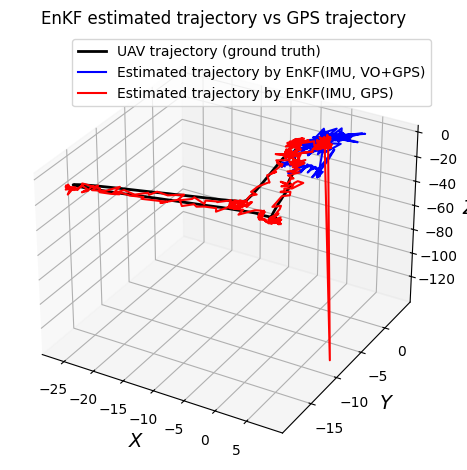

In [26]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("EnKF estimated trajectory vs GPS trajectory")

ax1.plot(px4_gps_df['north'].values, 
         px4_gps_df['east'].values, 
         px4_gps_df['down'].values, 
         label='UAV trajectory (ground truth)', 
         color='black', lw=2)
ax1.plot(enkf_mu_x, enkf_mu_y, enkf_mu_z, label='Estimated trajectory by EnKF(IMU, VO+GPS)', color='blue')
ax1.plot(enkf_imu_gps_mu_x, 
         enkf_imu_gps_mu_y, 
         enkf_imu_gps_mu_z, 
         label='Estimated trajectory by EnKF(IMU, GPS)', 
         color='red')

ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)
fig.tight_layout()

In [27]:
enkf_imu_vo_gps_error = get_error_report(px4_gps_df[gps_ned_pose_columns].values, 
                            np.array([enkf_mu_x, enkf_mu_y, enkf_mu_z]).T)
enkf_imu_gps_error = get_error_report(px4_gps_df[gps_ned_pose_columns].values, 
                            np.array([enkf_imu_gps_mu_x, enkf_imu_gps_mu_y, enkf_imu_gps_mu_z]).T)

print_error_report(
    report=enkf_imu_vo_gps_error,
    title="Deviation between EnKF(IMU, VO+GPS) estimated pose and GPS"
)

print_error_report(
    report=enkf_imu_gps_error,
    title="Deviation between EnKF(IMU, GPS) estimated pose and GPS"
)

----- Deviation between EnKF(IMU, VO+GPS) estimated pose and GPS -----
Mean Absolute Error: 5.153
Root Mean Squared Error: 7.539
Maximum Error: 26.947

----- Deviation between EnKF(IMU, GPS) estimated pose and GPS -----
Mean Absolute Error: 0.899
Root Mean Squared Error: 4.055
Maximum Error: 139.063



### CKF

In [28]:
x = np.array([
    [px4_gps_df.iloc[0]['north']],
    [px4_gps_df.iloc[0]['east']],
    [px4_gps_df.iloc[0]['down']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

ckf = CubatureKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1,
)

ckf_imu_gps = CubatureKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1,
)

In [29]:
t_last = df1.iloc[0]['timestamp']
df_reference = get_config(timestamp=t_last)
original_position = px4_gps_df[['lon', 'lat', 'alt']].iloc[0].values

ckf_mu_x = [x[0][0]]
ckf_mu_y = [x[1][0]]
ckf_mu_z = [x[2][0]]

ckf_imu_gps_mu_x = [x[0][0]]
ckf_imu_gps_mu_y = [x[1][0]]
ckf_imu_gps_mu_z = [x[2][0]]

for idx in tqdm(range(0, df1.shape[0])):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000
    # dt = (data_ref['timestamp'] - t_last) / 1_000_000 # delta time in second
    
    if dt < SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in time_update:
            # Call Time update step
            ckf.predict_setup1_2(u=data.values, dt=dt, Q=ckf.Q)
            ckf_imu_gps.predict_setup1_2(u=data.values, dt=dt, Q=ckf_imu_gps.Q)
    
        elif data_ref['device'] in measurement_update:
            # Call Measurement update step
            if data_ref['device'] == 'px4_gps':
                x_hat = ckf.x.copy()
                ckf_mu_x.append(x_hat[0, 0])
                ckf_mu_y.append(x_hat[1, 0])
                ckf_mu_z.append(x_hat[2, 0])
                x_hat2 = ckf_imu_gps.x.copy()
                ckf_imu_gps_mu_x.append(x_hat2[0, 0])
                ckf_imu_gps_mu_y.append(x_hat2[1, 0])
                ckf_imu_gps_mu_z.append(x_hat2[2, 0])
                
                gps_ned = lla_to_ned(
                    sensor["df"].iloc[sensor['index']:sensor['index'] + 1][gps_pose_columns].values.T,
                    original_position
                ).T[0]
                z = np.array([
                    gps_ned[0],
                    gps_ned[1],
                    gps_ned[2],
                ])
                ckf.update(z, R=ckf.R_gps)
                
                ckf_imu_gps.update(z, R=ckf_imu_gps.R_gps)
                
            elif data_ref['device'] == 'px4_vo':
                z = sensor["df"].iloc[sensor["index"]][vo_pos_columns].values
                r_vo = sensor["df"].iloc[sensor["index"]][vo_pos_var_columns].values
                if np.isnan(r_vo.sum()):
                    R_vo = ckf.R_vo
                else:
                    R_vo = np.eye(r_vo.shape[0]) * r_vo
                ckf.update(z, R=R_vo)
                
    # t_last = data_ref['timestamp']
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1

100%|█████████████████████████████████████████████████████████████████████████████████| 62219/62219 [00:47<00:00, 1310.68it/s]


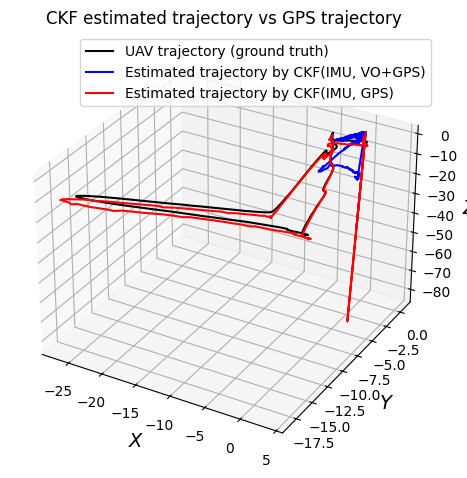

In [30]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("CKF estimated trajectory vs GPS trajectory")

ax1.plot(px4_gps_df['north'].values, 
         px4_gps_df['east'].values, 
         px4_gps_df['down'].values, 
         label='UAV trajectory (ground truth)', 
         color='black')
ax1.plot(ckf_mu_x, ckf_mu_y, ckf_mu_z, label='Estimated trajectory by CKF(IMU, VO+GPS)', color='blue')
ax1.plot(ckf_imu_gps_mu_x, ckf_imu_gps_mu_y, ckf_imu_gps_mu_z, label='Estimated trajectory by CKF(IMU, GPS)', color='red')

ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)
fig.tight_layout()

In [31]:
ckf_imu_vo_gps_error = get_error_report(px4_gps_df[gps_ned_pose_columns].values, 
                            np.array([ckf_mu_x, ckf_mu_y, ckf_mu_z]).T)
ckf_imu_gps_error = get_error_report(px4_gps_df[gps_ned_pose_columns].values, 
                            np.array([ckf_imu_gps_mu_x, ckf_imu_gps_mu_y, ckf_imu_gps_mu_z]).T)

print_error_report(
    report=ckf_imu_vo_gps_error,
    title="Deviation between CKF(IMU, VO+GPS) estimated pose and GPS"
)

print_error_report(
    report=ckf_imu_gps_error,
    title="Deviation between CKF(IMU, GPS) estimated pose and GPS"
)

----- Deviation between CKF(IMU, VO+GPS) estimated pose and GPS -----
Mean Absolute Error: 4.915
Root Mean Squared Error: 7.22
Maximum Error: 42.551

----- Deviation between CKF(IMU, GPS) estimated pose and GPS -----
Mean Absolute Error: 0.833
Root Mean Squared Error: 2.977
Maximum Error: 84.946



## Summary

In [32]:
def get_error_df(error_list):
    mae_error = get_error_from_list(error_list, e_type=ErrorEnum.MAE)
    
    rmse_error = get_error_from_list(error_list, e_type=ErrorEnum.RMSE)
    
    max_error = get_error_from_list(error_list, e_type=ErrorEnum.MAX)
    
    errors = np.array([
        mae_error, rmse_error, max_error
    ])
    df = pd.DataFrame(errors, 
                index=["MAE", "RMSE", "MAX"], 
                columns=["EKF", "UKF", "PF", "EnKF", "CKF"])
    return df

In [33]:
imu_vo_gps_error_df = get_error_df(error_list=[
            ekf_imu_vo_gps_error, 
            ukf_imu_vo_gps_error, 
            pf_imu_vo_gps_error, 
            enkf_imu_vo_gps_error, 
            ckf_imu_vo_gps_error
        ])
imu_gps_error_df = get_error_df(error_list=[
            ekf_imu_gps_error, 
            ukf_imu_gps_error, 
            pf_imu_gps_error, 
            enkf_imu_gps_error, 
            ckf_imu_gps_error
        ])

In [34]:
imu_vo_gps_error_df

,EKF,UKF,PF,EnKF,CKF
MAE,8.101,4.912,1656.924,5.153,4.915
RMSE,11.750,8.036,3266.243,7.539,7.220
MAX,30.402,141.621,12799.359,26.947,42.551


In [35]:
imu_gps_error_df

,EKF,UKF,PF,EnKF,CKF
MAE,14.600,3.488,2011.791,0.899,0.833
RMSE,24.629,10.474,4442.927,4.055,2.977
MAX,283.421,282.745,16390.529,139.063,84.946


Although the large deviation from the trajectory captured by px4 GPS observed at the begining, CKF corrects its estimate and grasp the flight trajectory pattern properly 

When Visual Odometry data provided by px4 is fed in measurement update step of each filter, the result shows that there is no difference among filters indicating that the estimations are unusable.

However, when IMU, logged by the voxl, and GPS are used in the filters, UKF, EnKF, and CKF provide a greate estimation. Moreover, CKF outperforms the other filters in MAE and RMSE. Although the large deviation from the trajectory captured by GPS at the begining, CKF corrects its estimation and grasps the flight trajectory pattern properly when GPS sensor data is available. 